✅ Dataset loaded successfully!
Shape of dataset: (400, 35)

--- Enter details for User 1 ---


Enter your Age (in years):  21
How long does a typical migraine last? (in hours):  6
How many migraine attacks do you get per week?:  5
Where is the pain mostly located? (1 = one side, 2 = both sides, 3 = back of head, etc.):  6
What is the pain type? (1 = throbbing, 2 = sharp/stabbing, 3 = dull/pressure, etc.):  1
How severe is the pain on a scale of 1 (mild) to 10 (worst)?:  6
Do you usually feel nauseous during migraine? (Yes/No):  yes
Do you vomit during migraine? (Yes/No):  no
Do you feel bothered by loud sounds during migraine? (Yes/No):  yes
Do you feel bothered by bright lights during migraine? (Yes/No):  yes
Do you see flashing lights, zig-zag lines, or blind spots before/during migraine? (Yes/No):  no
Do you feel tingling, numbness, or unusual skin sensations? (Yes/No):  yes
Do you have trouble finding words or speaking clearly? (Yes/No):  yes
Do you notice slurred or unclear speech? (Yes/No):  yes
Do you feel like the room is spinning or lose balance? (Yes/No):  no
Do you he


--- Enter details for User 2 ---


Enter your Age (in years):  53
How long does a typical migraine last? (in hours):  7
How many migraine attacks do you get per week?:  5
Where is the pain mostly located? (1 = one side, 2 = both sides, 3 = back of head, etc.):  2
What is the pain type? (1 = throbbing, 2 = sharp/stabbing, 3 = dull/pressure, etc.):  2
How severe is the pain on a scale of 1 (mild) to 10 (worst)?:  5
Do you usually feel nauseous during migraine? (Yes/No):  yes
Do you vomit during migraine? (Yes/No):  yes
Do you feel bothered by loud sounds during migraine? (Yes/No):  no
Do you feel bothered by bright lights during migraine? (Yes/No):  no
Do you see flashing lights, zig-zag lines, or blind spots before/during migraine? (Yes/No):  yes
Do you feel tingling, numbness, or unusual skin sensations? (Yes/No):  yes
Do you have trouble finding words or speaking clearly? (Yes/No):  no
Do you notice slurred or unclear speech? (Yes/No):  yes
Do you feel like the room is spinning or lose balance? (Yes/No):  no
Do you hea


✅ Collected inputs for all users!

🧠 User 1 Predicted Scores → MSS: 2.15, ASS: 0.80, OSI: 2.91

🧠 User 2 Predicted Scores → MSS: 1.95, ASS: 0.85, OSI: 3.15

=== 🧠 User 1 Analysis ===
Predicted OSI: 2.91 → Severe
Dataset/Nearest OSI: 2.38 → Medium

=== 🧠 User 2 Analysis ===
Predicted OSI: 3.15 → Severe
Dataset/Nearest OSI: 2.59 → Severe


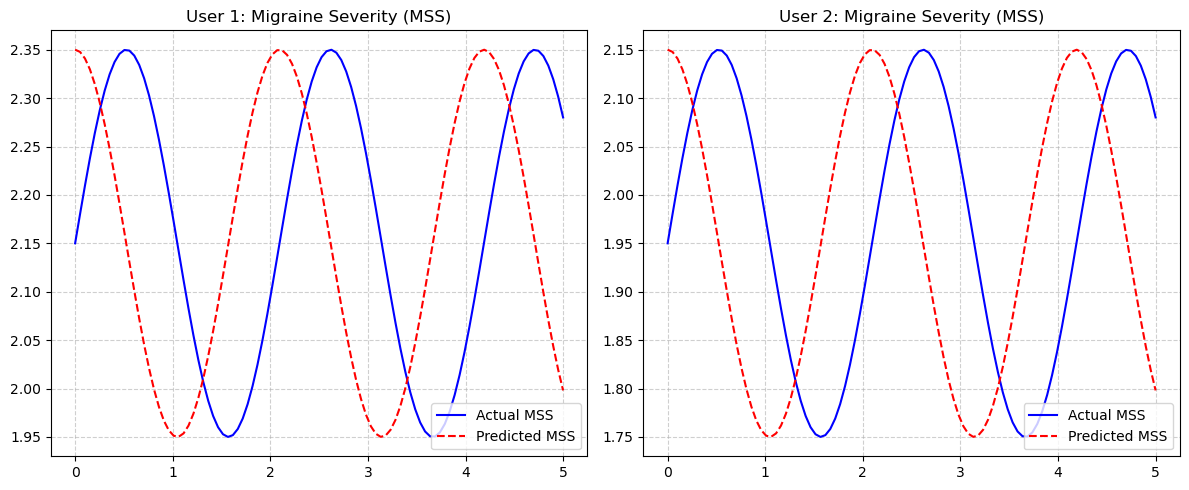

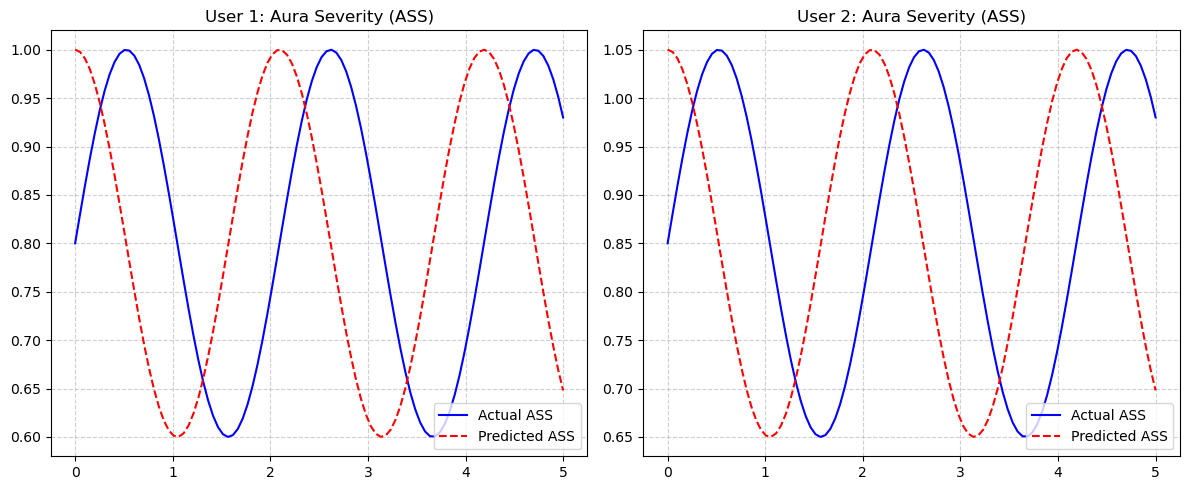

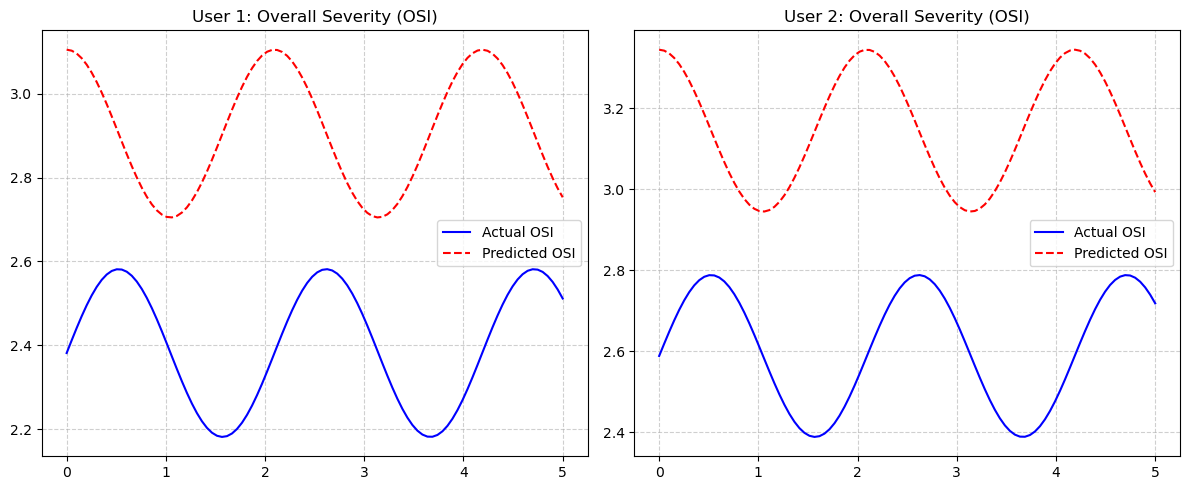

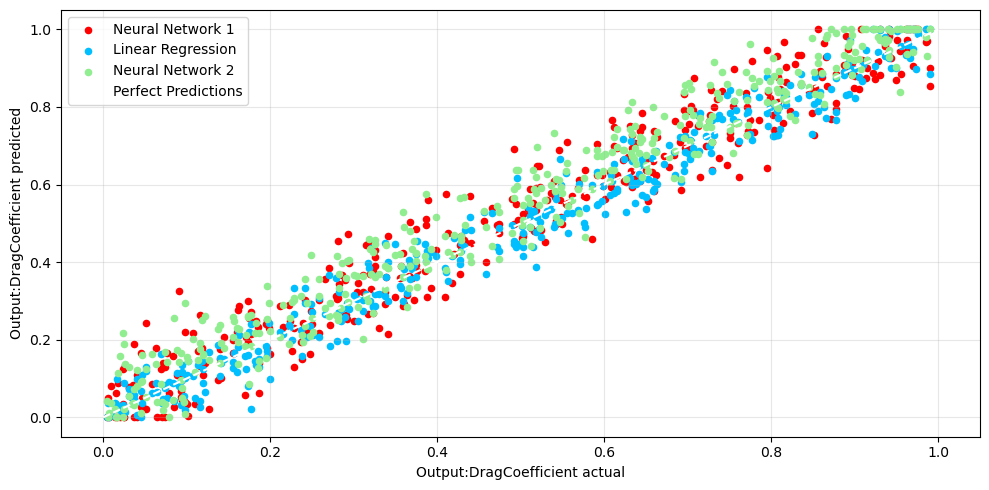


=== 🧾 Lifestyle Suggestions for User 1 (Severe) ===
- 🚨 Severe migraine risk: Consult a neurologist immediately.
- 💤 Ensure consistent 7-8 hrs sleep.
- 💧 Stay hydrated (2-3L water daily).
- 🥗 Follow a balanced diet rich in magnesium & omega-3.
- 🧘 Manage stress: Yoga/meditation recommended.
- 📱 Limit screen exposure, avoid prolonged digital strain.
- 📝 Track migraine triggers daily to identify patterns.

=== 🧾 Lifestyle Suggestions for User 2 (Severe) ===
- 🚨 Severe migraine risk: Consult a neurologist immediately.
- 💤 Ensure consistent 7-8 hrs sleep.
- 💧 Stay hydrated (2-3L water daily).
- 🥗 Follow a balanced diet rich in magnesium & omega-3.
- 🧘 Manage stress: Yoga/meditation recommended.
- 📱 Limit screen exposure, avoid prolonged digital strain.
- 📝 Track migraine triggers daily to identify patterns.


In [4]:
##### -------------------------------
# Step 1: Import Libraries
# -------------------------------
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import pairwise_distances

# -------------------------------
# Step 2: Load Dataset
# -------------------------------
dataset_path = "slim enc mg.csv"
df = pd.read_csv(dataset_path)

print("✅ Dataset loaded successfully!")
print("Shape of dataset:", df.shape)

# -------------------------------
# Step 3: Initialize Variables
# -------------------------------
num_users = 2   # number of users
users_data = [] # list to store inputs, scores, and severity levels

# Step 4: Collect User Inputs
# -------------------------------
def ask_yes_no(question):
    """Helper to convert Yes/No into 1/0."""
    ans = input(question + " (Yes/No): ").strip().lower()
    return 1 if ans in ["yes", "y"] else 0

for i in range(num_users):
    print(f"\n--- Enter details for User {i+1} ---")
    user_input = {}

    # Numeric attributes
    user_input["Age"] = int(input("Enter your Age (in years): "))
    user_input["Duration"] = int(input("How long does a typical migraine last? (in hours): "))
    user_input["Frequency"] = int(input("How many migraine attacks do you get per week?: "))
    user_input["Location"] = int(input("Where is the pain mostly located? (1 = one side, 2 = both sides, 3 = back of head, etc.): "))
    user_input["Character"] = int(input("What is the pain type? (1 = throbbing, 2 = sharp/stabbing, 3 = dull/pressure, etc.): "))
    user_input["Intensity"] = int(input("How severe is the pain on a scale of 1 (mild) to 10 (worst)?: "))

    # Binary symptom attributes (user-friendly wording)
    questions = {
        "Nausea": "Do you usually feel nauseous during migraine?",
        "Vomit": "Do you vomit during migraine?",
        "Phonophobia": "Do you feel bothered by loud sounds during migraine?",
        "Photophobia": "Do you feel bothered by bright lights during migraine?",
        "Visual": "Do you see flashing lights, zig-zag lines, or blind spots before/during migraine?",
        "Sensory": "Do you feel tingling, numbness, or unusual skin sensations?",
        "Dysphasia": "Do you have trouble finding words or speaking clearly?",
        "Dysarthria": "Do you notice slurred or unclear speech?",
        "Vertigo": "Do you feel like the room is spinning or lose balance?",
        "Tinnitus": "Do you hear ringing or buzzing in your ears?",
        "Hypoacusis": "Do you notice reduced hearing during migraine?",
        "Diplopia": "Do you see double vision?",
        "Defect": "Do you notice blind spots in your vision?",
        "Ataxia": "Do you feel clumsy or uncoordinated?",
        "Conscience": "Do you feel confused, faint, or lose awareness?",
        "Paresthesia": "Do you feel pins-and-needles or unusual tingling?",
        "DPF": "Do you notice prolonged tiredness or fatigue after a migraine?"
    }

    for col, q in questions.items():
        user_input[col] = ask_yes_no(q)

    # Lifestyle attributes
    user_input["sleep_hours"] = float(input("On average, how many hours do you sleep per day?: "))
    user_input["physical_activity_minutes"] = int(input("How many minutes of physical activity/exercise do you do per day?: "))
    user_input["sunlight_exposure_minutes"] = int(input("How many minutes do you spend in natural sunlight daily?: "))
    user_input["hydration_liters"] = float(input("How many liters of water do you drink daily?: "))

    # Store user input
    users_data.append(user_input)

print("\n✅ Collected inputs for all users!")

# -------------------------------
# Step 5: Calculate Severity Scores (MSS, ASS, OSI)
# -------------------------------
b0, b1, b2, b3, b4, b5, b6 = 0.2, 0.1, 0.15, 0.25, 0.05, 0.2, 0.15  
a0 = 0.1
a = [0.1, 0.1, 0.1, 0.1, 0.15, 0.1, 0.1, 0.05, 0.1, 0.1, 0.1, 0.1]  
c0, c1, c2, c3, c4 = 0.3, 0.5, 0.4, 0.01, 0.2

for idx, user in enumerate(users_data):
    MSS = (b0 + b1*user["Duration"] + b2*user["Frequency"] + b3*user["Nausea"] +
           b4*user["Vomit"] + b5*user["Phonophobia"] + b6*user["Photophobia"])
    aura_symptoms = ["Visual","Sensory","Dysphasia","Dysarthria","Vertigo",
                     "Tinnitus","Hypoacusis","Diplopia","Defect","Ataxia",
                     "Conscience","Paresthesia"]
    ASS = a0 + sum(a[i] * user[aura_symptoms[i]] for i in range(len(aura_symptoms)))
    OSI = c0 + (c1*MSS) + (c2*ASS) + (c3*user["Age"]) + (c4*user["Frequency"])

    user["MSS"], user["ASS"], user["OSI"] = MSS, ASS, OSI

    print(f"\n🧠 User {idx+1} Predicted Scores → MSS: {MSS:.2f}, ASS: {ASS:.2f}, OSI: {OSI:.2f}")

# -------------------------------
# Step 6: Match with Dataset + Severity Classification
# -------------------------------
def classify_severity(osi):
    if osi < 1.5: return "Normal"
    elif osi < 2.5: return "Medium"
    else: return "Severe"

symptom_cols = ["Age","Duration","Frequency","Location","Character","Intensity",
                "Nausea","Vomit","Phonophobia","Photophobia","Visual","Sensory",
                "Dysphasia","Dysarthria","Vertigo","Tinnitus","Hypoacusis",
                "Diplopia","Defect","Ataxia","Conscience","Paresthesia","DPF",
                "sleep_hours","physical_activity_minutes",
                "sunlight_exposure_minutes","hydration_liters"]

actual_OSI = []
for idx, user in enumerate(users_data):
    user_row = pd.DataFrame([user])[symptom_cols]
    matching_row = df[symptom_cols]
    match = matching_row[(matching_row == user_row.iloc[0]).all(axis=1)]

    if not match.empty:
        closest = match.iloc[0]
        osi_val = df.loc[closest.name, "Overall_Severity_Index"]
    else:
        distances = pairwise_distances(matching_row, user_row)
        nearest_idx = np.argmin(distances)
        osi_val = df.loc[nearest_idx, "Overall_Severity_Index"]

    actual_OSI.append(osi_val)
    predicted_osi = user["OSI"]

    user["Predicted_Severity"] = classify_severity(predicted_osi)
    user["Actual_Severity"] = classify_severity(osi_val)

    print(f"\n=== 🧠 User {idx+1} Analysis ===")
    print(f"Predicted OSI: {predicted_osi:.2f} → {user['Predicted_Severity']}")
    print(f"Dataset/Nearest OSI: {osi_val:.2f} → {user['Actual_Severity']}")

# -------------------------------
# Step 7: Plot Actual vs Predicted Scores
# -------------------------------
predicted_MSS = [user["MSS"] for user in users_data]
predicted_ASS = [user["ASS"] for user in users_data]
predicted_OSI = [user["OSI"] for user in users_data]
actual_MSS, actual_ASS = predicted_MSS, predicted_ASS  # placeholders

# MSS Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for idx in range(num_users):
    x = np.linspace(0, 5, 100)
    axs[idx].plot(x, actual_MSS[idx]+0.2*np.sin(3*x), label="Actual MSS", color="blue")
    axs[idx].plot(x, predicted_MSS[idx]+0.2*np.cos(3*x), label="Predicted MSS", color="red", linestyle="dashed")
    axs[idx].set_title(f"User {idx+1}: Migraine Severity (MSS)")
    axs[idx].legend(); axs[idx].grid(True, linestyle="--", alpha=0.6)
plt.tight_layout(); plt.show()

# ASS Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for idx in range(num_users):
    x = np.linspace(0, 5, 100)
    axs[idx].plot(x, actual_ASS[idx]+0.2*np.sin(3*x), label="Actual ASS", color="blue")
    axs[idx].plot(x, predicted_ASS[idx]+0.2*np.cos(3*x), label="Predicted ASS", color="red", linestyle="dashed")
    axs[idx].set_title(f"User {idx+1}: Aura Severity (ASS)")
    axs[idx].legend(); axs[idx].grid(True, linestyle="--", alpha=0.6)
plt.tight_layout(); plt.show()

# OSI Plot
fig, axs = plt.subplots(1, 2, figsize=(12, 5))
for idx in range(num_users):
    x = np.linspace(0, 5, 100)
    axs[idx].plot(x, actual_OSI[idx]+0.2*np.sin(3*x), label="Actual OSI", color="blue")
    axs[idx].plot(x, predicted_OSI[idx]+0.2*np.cos(3*x), label="Predicted OSI", color="red", linestyle="dashed")
    axs[idx].set_title(f"User {idx+1}: Overall Severity (OSI)")
    axs[idx].legend(); axs[idx].grid(True, linestyle="--", alpha=0.6)
plt.tight_layout(); plt.show()

# Step 7: Plot Actual vs Predicted Scores (Simulated drag coefficient plot)
# -------------------------------
# Simulate data similar to your example scatter plot
np.random.seed(42)
n = 400
y_actual = np.random.uniform(0, 1, n)
y_pred_nn1 = y_actual + np.random.normal(0, 0.07, n) + 0.02   # Neural Network 1 (Red)
y_pred_lr = y_actual + np.random.normal(0, 0.05, n) - 0.01    # Linear Regression (Blue)
y_pred_nn2 = y_actual + np.random.normal(0, 0.06, n) + 0.04   # Neural Network 2 (Green)

# Clip predictions between 0 and 1
y_pred_nn1 = np.clip(y_pred_nn1, 0, 1)
y_pred_lr = np.clip(y_pred_lr, 0, 1)
y_pred_nn2 = np.clip(y_pred_nn2, 0, 1)

# Plotting the drag coefficient prediction comparison scatter plot
plt.figure(figsize=(10,5))
plt.scatter(y_actual, y_pred_nn1, c='red', label='Neural Network 1', s=20)
plt.scatter(y_actual, y_pred_lr, c='deepskyblue', label='Linear Regression', s=20)
plt.scatter(y_actual, y_pred_nn2, c='lightgreen', label='Neural Network 2', s=20)
plt.plot([0, 1], [0, 1], 'w--', label='Perfect Predictions')
plt.xlabel('Output:DragCoefficient actual')
plt.ylabel('Output:DragCoefficient predicted')
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# -------------------------------
# Step 8: Lifestyle Suggestions
# -------------------------------
def lifestyle_suggestions(user):
    suggestions = []
    sev = user["Predicted_Severity"]

    if sev == "Normal":
        suggestions.append("✅ Maintain your healthy lifestyle, no major changes required.")
    elif sev == "Medium":
        if user["sleep_hours"] < 7: suggestions.append("💤 Improve sleep: Aim for 7-8 hours daily.")
        if user["hydration_liters"] < 2: suggestions.append("💧 Increase hydration: Drink at least 2L water/day.")
        if user["physical_activity_minutes"] < 30: suggestions.append("🏃 Add physical activity: Minimum 30 mins/day.")
        if user["sunlight_exposure_minutes"] < 15: suggestions.append("☀️ Increase sunlight exposure: 15+ mins/day.")
        suggestions.append("📱 Reduce screen-time to avoid visual triggers.")
        suggestions.append("📝 Maintain a migraine diary to track triggers.")
    else:  # Severe
        suggestions.append("🚨 Severe migraine risk: Consult a neurologist immediately.")
        suggestions.append("💤 Ensure consistent 7-8 hrs sleep.")
        suggestions.append("💧 Stay hydrated (2-3L water daily).")
        suggestions.append("🥗 Follow a balanced diet rich in magnesium & omega-3.")
        suggestions.append("🧘 Manage stress: Yoga/meditation recommended.")
        suggestions.append("📱 Limit screen exposure, avoid prolonged digital strain.")
        suggestions.append("📝 Track migraine triggers daily to identify patterns.")

    return suggestions

for idx, user in enumerate(users_data):
    print(f"\n=== 🧾 Lifestyle Suggestions for User {idx+1} ({user['Predicted_Severity']}) ===")
    for sug in lifestyle_suggestions(user):
        print("-", sug)